# `cqed_sim` Usage Examples

This notebook is a compact gallery of practical `cqed_sim` workflows aimed at experimental cQED users.

**Physics assumptions and conventions used below**

- Internal frequencies are in `rad/s` and times are in `s`.
- Tensor ordering is qubit first, then storage cavity, then readout if present.
- Several examples work in a rotating frame using `FrameSpec(...)`, so scanned carriers are detunings around zero in that frame.
- The transmon is often truncated to two levels when the goal is a clean qubit-control signature rather than leakage analysis.
- The readout-chain example uses the experiment-layer effective resonator/filter/amplifier model rather than embedding the full chain inside the QuTiP Lindblad solver.

The examples intentionally expose the public API: model creation, pulse definition, sequence compilation, simulation, and observable extraction.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from cqed_sim import (
    AmplifierChain,
    DispersiveReadoutTransmonStorageModel,
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    NoiseSpec,
    Pulse,
    PurcellFilter,
    QubitMeasurementSpec,
    ReadoutChain,
    ReadoutResonator,
    RotationGate,
    SQRGate,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    build_displacement_pulse,
    build_rotation_pulse,
    build_sqr_multitone_pulse,
    cavity_wigner,
    coherent_state,
    conditioned_bloch_xyz,
    measure_qubit,
    prepare_state,
    qubit_state,
    reduced_cavity_state,
    simulate_sequence,
)
from cqed_sim.pulses import gaussian_envelope, square_envelope
from physics_and_conventions import from_internal_units, to_internal_units

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ns = 1.0e-9
us = 1.0e-6

def GHz(value: float) -> float:
    return to_internal_units(value * 1.0e9)

def MHz(value: float) -> float:
    return to_internal_units(value * 1.0e6)

def shift_pulse(pulse: Pulse, *, t0: float | None = None, carrier: float | None = None, phase: float | None = None, label: str | None = None) -> Pulse:
    return Pulse(
        channel=pulse.channel,
        t0=pulse.t0 if t0 is None else float(t0),
        duration=pulse.duration,
        envelope=pulse.envelope,
        carrier=pulse.carrier if carrier is None else float(carrier),
        phase=pulse.phase if phase is None else float(phase),
        amp=pulse.amp,
        drag=pulse.drag,
        sample_rate=pulse.sample_rate,
        label=pulse.label if label is None else label,
    )

def spectroscopy_envelope(t_rel: np.ndarray) -> np.ndarray:
    env = np.asarray(gaussian_envelope(t_rel, sigma=1.0 / 6.0), dtype=np.complex128)
    mean_val = float(np.mean(np.real(env)))
    return env / mean_val if abs(mean_val) > 1.0e-12 else env


## 1. Basic Model Construction

Start by constructing the effective Hamiltonian models. The two-mode model is the usual transmon plus storage cavity path. The three-mode model adds an explicit readout resonator.


In [2]:
two_mode_model = DispersiveTransmonCavityModel(
    omega_c=GHz(6.20),
    omega_q=GHz(5.00),
    alpha=MHz(-220.0),
    chi=MHz(2.8),
    kerr=MHz(-0.020),
    n_cav=10,
    n_tr=3,
)

three_mode_model = DispersiveReadoutTransmonStorageModel(
    omega_s=GHz(6.20),
    omega_r=GHz(7.35),
    omega_q=GHz(5.00),
    alpha=MHz(-220.0),
    chi_s=MHz(2.8),
    chi_r=MHz(1.4),
    chi_sr=MHz(0.030),
    kerr_s=MHz(-0.020),
    kerr_r=MHz(-0.040),
    n_storage=8,
    n_readout=10,
    n_tr=3,
)

two_mode_frame = FrameSpec(
    omega_c_frame=two_mode_model.omega_c,
    omega_q_frame=two_mode_model.omega_q,
)
three_mode_frame = FrameSpec(
    omega_c_frame=three_mode_model.omega_s,
    omega_q_frame=three_mode_model.omega_q,
    omega_r_frame=three_mode_model.omega_r,
)


In [3]:
print("Two-mode subsystem dims:", two_mode_model.subsystem_dims)
print("Two-mode operator keys:", sorted(two_mode_model.operators()))
print("Two-mode qubit transition at n=3:", f"{from_internal_units(two_mode_model.manifold_transition_frequency(3, frame=two_mode_frame)) / 1e9:.6f} GHz")

print()
print("Three-mode subsystem dims:", three_mode_model.subsystem_dims)
print("Three-mode operator keys:", sorted(three_mode_model.operators()))
print(
    "Three-mode readout transition for |g,0,n_r>:",
    f"{from_internal_units(three_mode_model.readout_transition_frequency(qubit_level=0, storage_level=0, readout_level=0, frame=three_mode_frame)) / 1e6:.3f} MHz in the chosen frame",
)
print(
    "Three-mode readout transition for |e,0,n_r>:",
    f"{from_internal_units(three_mode_model.readout_transition_frequency(qubit_level=1, storage_level=0, readout_level=0, frame=three_mode_frame)) / 1e6:.3f} MHz in the chosen frame",
)


Two-mode subsystem dims: (3, 10)
Two-mode operator keys: ['a', 'adag', 'b', 'bdag', 'n_c', 'n_q']
Two-mode qubit transition at n=3: -0.008400 GHz

Three-mode subsystem dims: (3, 8, 10)
Three-mode operator keys: ['a_r', 'a_s', 'adag_r', 'adag_s', 'b', 'bdag', 'n_q', 'n_r', 'n_s']
Three-mode readout transition for |g,0,n_r>: 0.000 MHz in the chosen frame
Three-mode readout transition for |e,0,n_r>: -1.400 MHz in the chosen frame


**Takeaway.** The model classes already encode the truncation, dispersive shifts, and mode ordering. In practice you usually choose a rotating frame immediately, then build pulses and sweeps around detunings in that frame.


## 2. Bare Qubit Spectroscopy

A simple spectroscopy experiment is a weak, long qubit drive while sweeping the drive frequency. Here the cavity is idle and the qubit is modeled as an effective two-level system for clarity.


In [4]:
spectroscopy_model = DispersiveTransmonCavityModel(
    omega_c=GHz(6.20),
    omega_q=GHz(5.00),
    alpha=0.0,
    chi=0.0,
    kerr=0.0,
    n_cav=2,
    n_tr=2,
)
spectroscopy_frame = FrameSpec(omega_q_frame=spectroscopy_model.omega_q)

spectroscopy_detunings_mhz = np.linspace(-2.0, 2.0, 201)
spectroscopy_duration = 10000 * ns
spectroscopy_amp = MHz(0.1)


In [5]:
spectroscopy_response = []
for detuning_mhz in spectroscopy_detunings_mhz:
    pulse = Pulse(
        "q",
        t0=0.0,
        duration=spectroscopy_duration,
        envelope=square_envelope,
        carrier=MHz(detuning_mhz),
        amp=spectroscopy_amp,
        label="spec_probe",
    )
    compiled = SequenceCompiler(dt=4 * ns).compile([pulse], t_end=spectroscopy_duration + 4 * ns)
    result = simulate_sequence(
        spectroscopy_model,
        compiled,
        spectroscopy_model.basis_state(0, 0),
        {"q": "qubit"},
        SimulationConfig(frame=spectroscopy_frame, max_step=4 * ns),
    )
    spectroscopy_response.append(float(result.expectations["P_e"][-1]))

spectroscopy_response = np.asarray(spectroscopy_response, dtype=float)
spectroscopy_peak_mhz = float(spectroscopy_detunings_mhz[int(np.argmax(spectroscopy_response))])


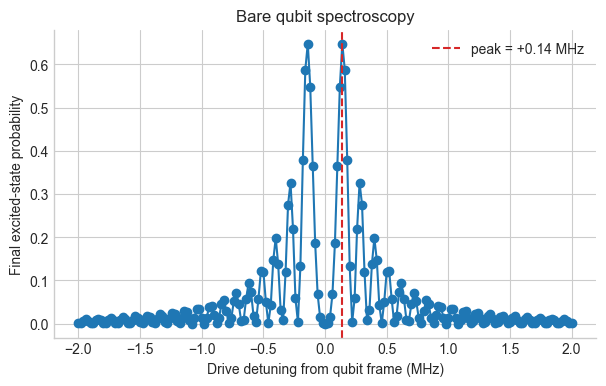

Spectroscopy peak detuning: +0.14 MHz


In [6]:
fig, ax = plt.subplots()
ax.plot(spectroscopy_detunings_mhz, spectroscopy_response, marker="o", lw=1.5)
ax.axvline(spectroscopy_peak_mhz, color="tab:red", ls="--", label=f"peak = {spectroscopy_peak_mhz:+.2f} MHz")
ax.set_xlabel("Drive detuning from qubit frame (MHz)")
ax.set_ylabel("Final excited-state probability")
ax.set_title("Bare qubit spectroscopy")
ax.legend()
plt.show()

print(f"Spectroscopy peak detuning: {spectroscopy_peak_mhz:+.2f} MHz")


**Takeaway.** The workflow is explicit: define a weak probe pulse, compile a sequence, sweep the carrier detuning, and read out `P_e` from `result.expectations`.


## 3. Qubit Rabi Oscillation

For a resonant drive, varying the pulse duration maps out Rabi oscillations. This is one of the simplest time-domain calibrations.


In [7]:
rabi_model = DispersiveTransmonCavityModel(
    omega_c=GHz(6.20),
    omega_q=GHz(5.00),
    alpha=0.0,
    chi=0.0,
    kerr=0.0,
    n_cav=2,
    n_tr=2,
)
rabi_frame = FrameSpec(omega_q_frame=rabi_model.omega_q)

rabi_durations = np.linspace(0.0, 250 * ns, 31)
rabi_amp = MHz(4.0)


In [8]:
rabi_response = []
for duration in rabi_durations:
    pulses = []
    drive_ops = {}
    if duration > 0.0:
        pulses = [Pulse("q", 0.0, float(duration), square_envelope, carrier=0.0, amp=rabi_amp, label="rabi_drive")]
        drive_ops = {"q": "qubit"}
    compiled = SequenceCompiler(dt=2 * ns).compile(pulses, t_end=float(duration) + 2 * ns)
    result = simulate_sequence(
        rabi_model,
        compiled,
        rabi_model.basis_state(0, 0),
        drive_ops,
        SimulationConfig(frame=rabi_frame, max_step=2 * ns),
    )
    rabi_response.append(float(result.expectations["P_e"][-1]))

rabi_response = np.asarray(rabi_response, dtype=float)
rabi_pi_time_ns = float(rabi_durations[int(np.argmax(rabi_response))] / ns)


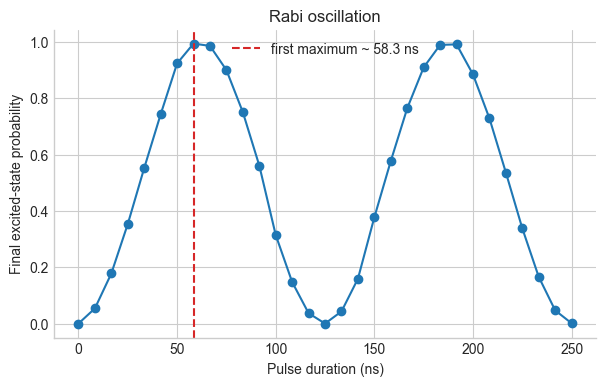

Estimated pi-pulse duration at this amplitude: 58.3 ns


In [9]:
fig, ax = plt.subplots()
ax.plot(rabi_durations / ns, rabi_response, marker="o", lw=1.5)
ax.axvline(rabi_pi_time_ns, color="tab:red", ls="--", label=f"first maximum ~ {rabi_pi_time_ns:.1f} ns")
ax.set_xlabel("Pulse duration (ns)")
ax.set_ylabel("Final excited-state probability")
ax.set_title("Rabi oscillation")
ax.legend()
plt.show()

print(f"Estimated pi-pulse duration at this amplitude: {rabi_pi_time_ns:.1f} ns")


**Takeaway.** A Rabi calibration is just a family of resonant pulses with one parameter varied. The pulse amplitude is written directly in the Hamiltonian units used by the runtime.


## 4. Ramsey Experiment

A Ramsey sequence uses two nominal `X/2` pulses separated by free evolution. Here the qubit is detuned by `2 MHz` in the chosen rotating frame, and we also include a mild pure-dephasing channel.


In [10]:
ramsey_detuning = MHz(2.0)
ramsey_reference_frequency = GHz(5.00)
ramsey_model = DispersiveTransmonCavityModel(
    omega_c=0.0,
    omega_q=ramsey_reference_frequency + ramsey_detuning,
    alpha=0.0,
    chi=0.0,
    kerr=0.0,
    n_cav=2,
    n_tr=2,
)
ramsey_frame = FrameSpec(omega_q_frame=ramsey_reference_frequency)
ramsey_noise = NoiseSpec(tphi=6.0 * us)

x90_pulses, x90_drive_ops, _ = build_rotation_pulse(
    RotationGate(index=0, name="x90", theta=np.pi / 2.0, phi=0.0),
    {"duration_rotation_s": 40 * ns, "rotation_sigma_fraction": 0.18},
)
x90_template = x90_pulses[0]
ramsey_delays = np.linspace(0.0, 1.0 * us, 31)


In [11]:
ramsey_response = []
for delay in ramsey_delays:
    pulse_1 = x90_template
    pulse_2 = shift_pulse(x90_template, t0=x90_template.t1 + float(delay), label="x90_2")
    compiled = SequenceCompiler(dt=2 * ns).compile([pulse_1, pulse_2], t_end=pulse_2.t1 + 2 * ns)
    result = simulate_sequence(
        ramsey_model,
        compiled,
        ramsey_model.basis_state(0, 0),
        x90_drive_ops,
        SimulationConfig(frame=ramsey_frame, max_step=2 * ns),
        noise=ramsey_noise,
    )
    ramsey_response.append(float(result.expectations["P_e"][-1]))

ramsey_response = np.asarray(ramsey_response, dtype=float)
centered_signal = ramsey_response - np.mean(ramsey_response)
freq_axis_hz = np.fft.rfftfreq(ramsey_delays.size, d=float(ramsey_delays[1] - ramsey_delays[0]))
fft_power = np.abs(np.fft.rfft(centered_signal))
dominant_idx = 1 + int(np.argmax(fft_power[1:]))
ramsey_fit_mhz = float(freq_axis_hz[dominant_idx] / 1.0e6)


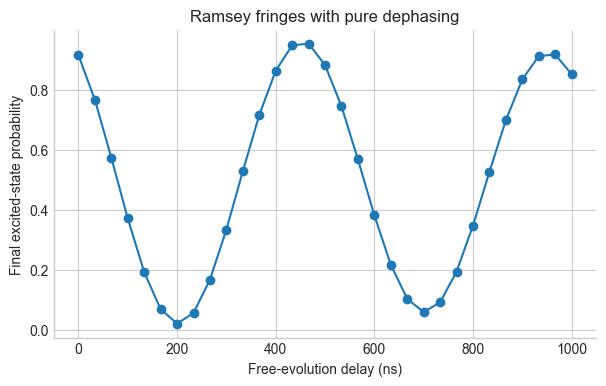

Configured detuning: 2.00 MHz
Dominant fringe frequency from the coarse FFT: 1.94 MHz


In [12]:
fig, ax = plt.subplots()
ax.plot(ramsey_delays / ns, ramsey_response, marker="o", lw=1.5)
ax.set_xlabel("Free-evolution delay (ns)")
ax.set_ylabel("Final excited-state probability")
ax.set_title("Ramsey fringes with pure dephasing")
plt.show()

print(f"Configured detuning: {from_internal_units(ramsey_detuning) / 1.0e6:.2f} MHz")
print(f"Dominant fringe frequency from the coarse FFT: {ramsey_fit_mhz:.2f} MHz")


**Takeaway.** In a Ramsey simulation the qubit-frame choice matters directly. The drift `omega_q - omega_q_frame` generates the phase accumulation during the free-evolution window, while `NoiseSpec(tphi=...)` damps the fringe contrast.


## 5. Cavity Displacement Followed by Qubit Spectroscopy

This is the classic dispersive signature: displace the cavity into a coherent superposition of Fock states, then probe the qubit. Each photon number shifts the qubit transition by roughly `-chi`.


In [13]:
dispersive_model = DispersiveTransmonCavityModel(
    omega_c=0.0,
    omega_q=0.0,
    alpha=0.0,
    chi=MHz(-3.0),
    kerr=0.0,
    n_cav=12,
    n_tr=2,
)
dispersive_frame = FrameSpec(omega_q_frame=dispersive_model.omega_q)

displacement_gate = DisplacementGate(index=0, name="prep_alpha", re=1.0, im=0.0)
displacement_pulses, displacement_drive_ops, displacement_meta = build_displacement_pulse(
    displacement_gate,
    {"duration_displacement_s": 80 * ns},
)

spectroscopy_detunings_mhz = np.linspace(-15.0, 2.0, 101)
spectroscopy_probe = {
    "t0": 100 * ns,
    "duration": 2.0 * us,
    "amp": MHz(0.1),
}


In [14]:
displacement_only = SequenceCompiler(dt=2 * ns).compile(displacement_pulses, t_end=82 * ns)
displaced_state = simulate_sequence(
    dispersive_model,
    displacement_only,
    dispersive_model.basis_state(0, 0),
    displacement_drive_ops,
    SimulationConfig(max_step=2 * ns),
).final_state

cavity_rho = reduced_cavity_state(displaced_state)
fock_probabilities = np.real(np.diag(cavity_rho.full()))
fock_probabilities = np.clip(fock_probabilities, 0.0, None)
fock_probabilities /= np.sum(fock_probabilities)
displaced_nbar = float(np.real(qt.expect(dispersive_model.operators()["n_c"], displaced_state)))

displaced_spectroscopy = []
for detuning_mhz in spectroscopy_detunings_mhz:
    probe = Pulse(
        "q",
        t0=spectroscopy_probe["t0"],
        duration=spectroscopy_probe["duration"],
        envelope=spectroscopy_envelope,
        carrier=MHz(detuning_mhz),
        amp=spectroscopy_probe["amp"],
        label="selective_qubit_probe",
    )
    compiled = SequenceCompiler(dt=4 * ns).compile(
        list(displacement_pulses) + [probe],
        t_end=spectroscopy_probe["t0"] + spectroscopy_probe["duration"] + 4 * ns,
    )
    result = simulate_sequence(
        dispersive_model,
        compiled,
        dispersive_model.basis_state(0, 0),
        {**displacement_drive_ops, "q": "qubit"},
        SimulationConfig(frame=dispersive_frame, max_step=4 * ns),
    )
    displaced_spectroscopy.append(float(result.expectations["P_e"][-1]))

displaced_spectroscopy = np.asarray(displaced_spectroscopy, dtype=float)
chi_mhz = from_internal_units(dispersive_model.chi) / 1.0e6
predicted_lines_mhz = np.arange(6) * chi_mhz


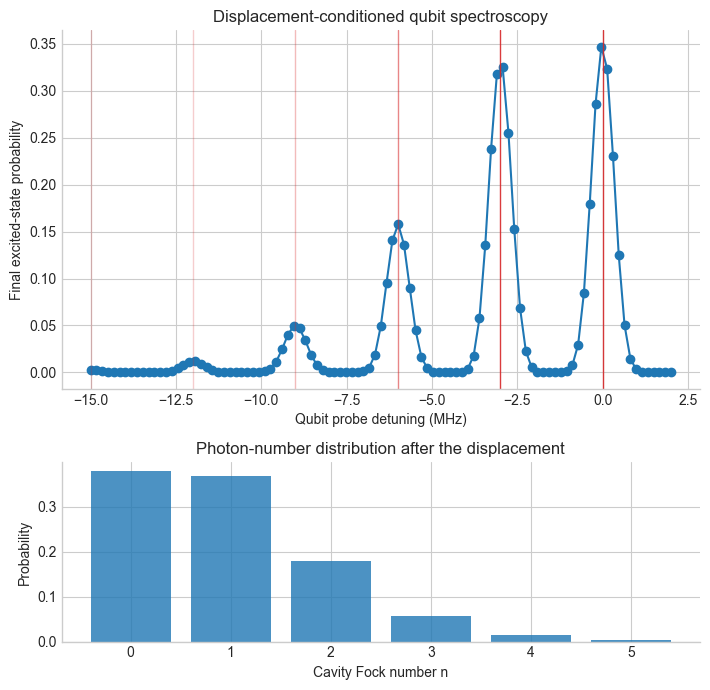

Requested displacement alpha: 1.00
Mean photon number after the pulse: 0.969
Dispersive pull chi: -3.00 MHz per photon


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(7.2, 7.0), height_ratios=[2.0, 1.0])

axes[0].plot(spectroscopy_detunings_mhz, displaced_spectroscopy, marker="o", lw=1.5, label="simulated $P_e$")
for n, line_mhz in enumerate(predicted_lines_mhz):
    if fock_probabilities[n] < 1.0e-3:
        continue
    axes[0].axvline(
        line_mhz,
        color="tab:red",
        alpha=min(0.9, 0.2 + 2.0 * fock_probabilities[n]),
        lw=1.0,
    )
axes[0].set_xlabel("Qubit probe detuning (MHz)")
axes[0].set_ylabel("Final excited-state probability")
axes[0].set_title("Displacement-conditioned qubit spectroscopy")

axes[1].bar(np.arange(6), fock_probabilities[:6], color="tab:blue", alpha=0.8)
axes[1].set_xlabel("Cavity Fock number n")
axes[1].set_ylabel("Probability")
axes[1].set_title("Photon-number distribution after the displacement")

fig.tight_layout()
plt.show()

print(f"Requested displacement alpha: {displacement_gate.alpha.real:.2f}")
print(f"Mean photon number after the pulse: {displaced_nbar:.3f}")
print(f"Dispersive pull chi: {chi_mhz:+.2f} MHz per photon")


**Takeaway.** The displacement populates several Fock states at once, and the qubit spectrum resolves those manifolds because the Hamiltonian includes `-chi * n_c * n_q`.


## 6. AC Stark Shift Versus Displacement Amplitude

A coherent displacement changes the cavity occupation and therefore shifts the qubit spectrum. To keep this section lightweight, we summarize each simulated spectrum by its response-weighted centroid rather than by a more elaborate multi-peak fit.


In [16]:
stark_amplitudes = np.linspace(0.3, 1.3, 6)
stark_detunings_mhz = np.linspace(-10.0, 1.0, 23)


In [17]:
stark_nbar = []
stark_centroids_mhz = []

for alpha_re in stark_amplitudes:
    gate = DisplacementGate(index=0, name=f"alpha_{alpha_re:.2f}", re=float(alpha_re), im=0.0)
    pulses, drive_ops, _ = build_displacement_pulse(gate, {"duration_displacement_s": 80 * ns})

    displaced = simulate_sequence(
        dispersive_model,
        SequenceCompiler(dt=2 * ns).compile(pulses, t_end=82 * ns),
        dispersive_model.basis_state(0, 0),
        drive_ops,
        SimulationConfig(max_step=2 * ns),
    ).final_state
    stark_nbar.append(float(np.real(qt.expect(dispersive_model.operators()["n_c"], displaced))))

    response = []
    for detuning_mhz in stark_detunings_mhz:
        probe = Pulse(
            "q",
            t0=100 * ns,
            duration=1.5 * us,
            envelope=spectroscopy_envelope,
            carrier=MHz(detuning_mhz),
            amp=MHz(0.8),
        )
        compiled = SequenceCompiler(dt=4 * ns).compile(
            list(pulses) + [probe],
            t_end=1.604 * us,
        )
        result = simulate_sequence(
            dispersive_model,
            compiled,
            dispersive_model.basis_state(0, 0),
            {**drive_ops, "q": "qubit"},
            SimulationConfig(frame=dispersive_frame, max_step=4 * ns),
        )
        response.append(float(result.expectations["P_e"][-1]))

    response = np.asarray(response, dtype=float)
    stark_centroids_mhz.append(float(np.sum(stark_detunings_mhz * response) / np.sum(response)))

stark_nbar = np.asarray(stark_nbar, dtype=float)
stark_centroids_mhz = np.asarray(stark_centroids_mhz, dtype=float)
linear_prediction_mhz = chi_mhz * stark_nbar


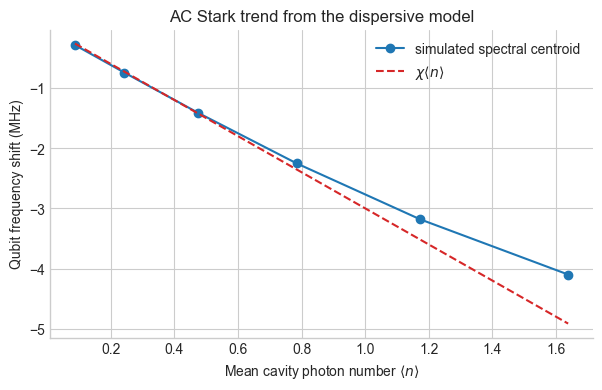

Linear fit to the simulated trend: -2.48 MHz / photon
Model chi: -3.00 MHz / photon


In [18]:
fig, ax = plt.subplots()
ax.plot(stark_nbar, stark_centroids_mhz, marker="o", lw=1.5, label="simulated spectral centroid")
ax.plot(stark_nbar, linear_prediction_mhz, ls="--", color="tab:red", label=r"$\chi \langle n \rangle$")
ax.set_xlabel(r"Mean cavity photon number $\langle n \rangle$")
ax.set_ylabel("Qubit frequency shift (MHz)")
ax.set_title("AC Stark trend from the dispersive model")
ax.legend()
plt.show()

slope_mhz_per_photon = np.polyfit(stark_nbar, stark_centroids_mhz, deg=1)[0]
print(f"Linear fit to the simulated trend: {slope_mhz_per_photon:+.2f} MHz / photon")
print(f"Model chi: {chi_mhz:+.2f} MHz / photon")


**Takeaway.** In this effective model the AC Stark shift emerges directly from the same dispersive Hamiltonian used in the selective spectroscopy example, and the fitted slope tracks the configured `chi`.


## 7. Readout Resonator Response Conditioned on Qubit State

`cqed_sim` now has an experiment-layer readout chain. This example uses the effective resonator → Purcell filter → amplifier → I/Q integration model to show how the response differs for `|g>` and `|e>`.


In [19]:
readout_chain = ReadoutChain(
    resonator=ReadoutResonator(
        omega_r=GHz(7.00),
        kappa=MHz(8.0),
        g=MHz(90.0),
        epsilon=MHz(0.6),
        chi=MHz(1.5),
    ),
    purcell_filter=PurcellFilter(omega_f=GHz(7.00), bandwidth=MHz(40.0)),
    amplifier=AmplifierChain(noise_temperature=4.0, gain=12.0),
    integration_time=300 * ns,
    dt=5 * ns,
)


In [20]:
trace_g = readout_chain.simulate_trace("g", include_noise=False)
trace_e = readout_chain.simulate_trace("e", include_noise=False)

measurement_spec = QubitMeasurementSpec(
    shots=250,
    seed=7,
    readout_chain=readout_chain,
    readout_duration=readout_chain.integration_time,
    readout_dt=readout_chain.dt,
    classify_from_iq=True,
)
measured_g = measure_qubit(qt.tensor(qt.basis(2, 0), qt.basis(2, 0)), measurement_spec)
measured_e = measure_qubit(qt.tensor(qt.basis(2, 1), qt.basis(2, 0)), measurement_spec)


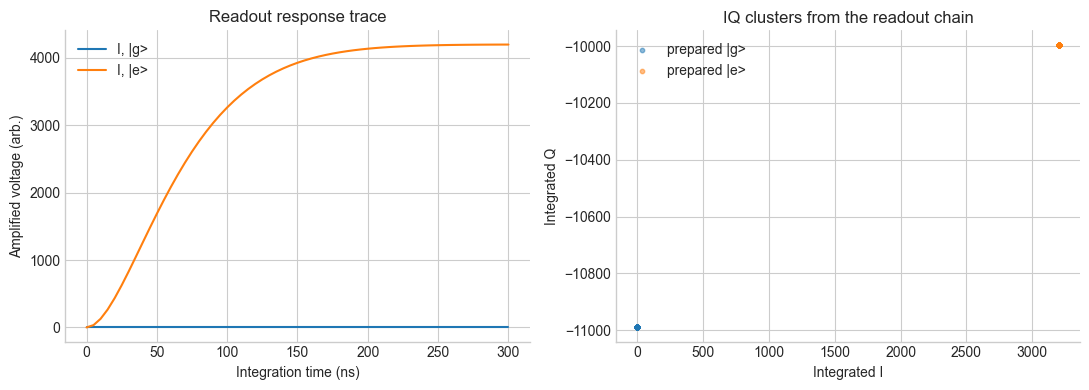

Measurement-induced dephasing rate: 11.10 kHz
Purcell-limited T1 at 6.0 GHz qubit frequency: 6142.7 us


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

axes[0].plot(trace_g.tlist / ns, np.real(trace_g.voltage_trace), label="I, |g>")
axes[0].plot(trace_g.tlist / ns, np.real(trace_e.voltage_trace), label="I, |e>")
axes[0].set_xlabel("Integration time (ns)")
axes[0].set_ylabel("Amplified voltage (arb.)")
axes[0].set_title("Readout response trace")
axes[0].legend()

axes[1].scatter(measured_g.iq_samples[:, 0], measured_g.iq_samples[:, 1], s=10, alpha=0.5, label="prepared |g>")
axes[1].scatter(measured_e.iq_samples[:, 0], measured_e.iq_samples[:, 1], s=10, alpha=0.5, label="prepared |e>")
axes[1].set_xlabel("Integrated I")
axes[1].set_ylabel("Integrated Q")
axes[1].set_title("IQ clusters from the readout chain")
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"Measurement-induced dephasing rate: {from_internal_units(readout_chain.gamma_meas()) / 1.0e3:.2f} kHz")
print(f"Purcell-limited T1 at 6.0 GHz qubit frequency: {readout_chain.purcell_limited_t1(GHz(6.0)) / us:.1f} us")


**Takeaway.** The readout-chain API is separate from the core QuTiP solver path, but it uses the same frequency conventions and now provides a practical user-facing route to conditioned resonator response, I/Q sampling, `gamma_meas`, and Purcell-limited `T1`.


## 8. Coherent-State Cavity Dynamics

A common cavity experiment is to prepare a coherent state and watch it decay. This example uses the reusable state-preparation API plus a simple cavity damping channel.


In [22]:
coherent_model = DispersiveTransmonCavityModel(
    omega_c=0.0,
    omega_q=0.0,
    alpha=0.0,
    chi=0.0,
    kerr=-30e3,
    n_cav=18,
    n_tr=2,
)
coherent_initial_state = prepare_state(
    coherent_model,
    StatePreparationSpec(
        qubit=qubit_state("g"),
        storage=coherent_state(1.5),
    ),
)
coherent_compiled = SequenceCompiler(dt=20 * ns).compile([], t_end=100.0 * us)


In [23]:
coherent_result = simulate_sequence(
    coherent_model,
    coherent_compiled,
    coherent_initial_state,
    {},
    SimulationConfig(store_states=True),
    noise=NoiseSpec(kappa=1.0 / (250 * us)),
)

coherent_n_t = np.asarray(coherent_result.expectations["n_c"], dtype=float)
cavity_rho_initial = reduced_cavity_state(coherent_initial_state)
cavity_rho_final = reduced_cavity_state(coherent_result.final_state)
p_n_initial = np.real(np.diag(cavity_rho_initial.full()))
p_n_final = np.real(np.diag(cavity_rho_final.full()))
x_w, y_w, w_initial = cavity_wigner(cavity_rho_initial, n_points=31, extent=4.0)
_, _, w_final = cavity_wigner(cavity_rho_final, n_points=31, extent=4.0)


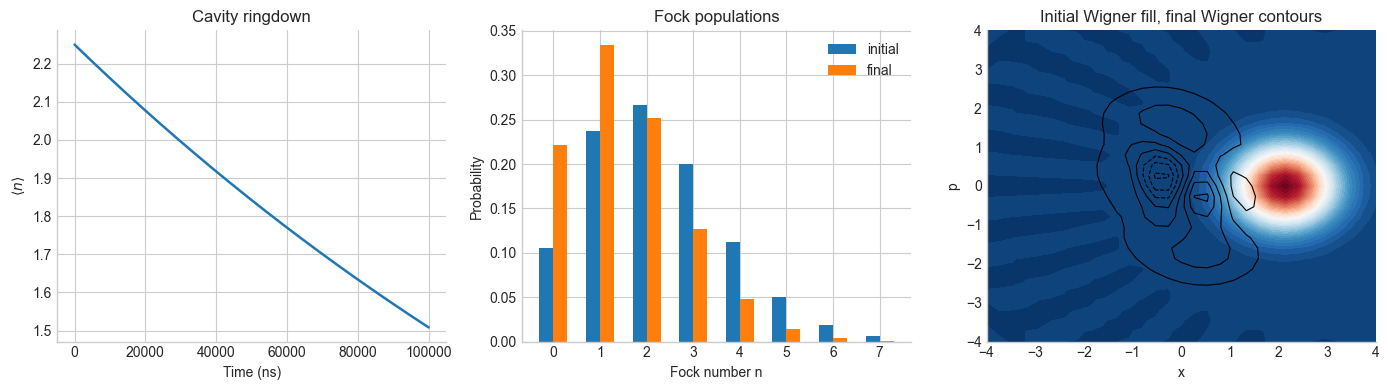

Initial mean photon number: 2.250
Final mean photon number: 1.508


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.0))

axes[0].plot(coherent_compiled.tlist / ns, coherent_n_t, lw=1.8)
axes[0].set_xlabel("Time (ns)")
axes[0].set_ylabel(r"$\langle n \rangle$")
axes[0].set_title("Cavity ringdown")

axes[1].bar(np.arange(8) - 0.15, p_n_initial[:8], width=0.3, label="initial")
axes[1].bar(np.arange(8) + 0.15, p_n_final[:8], width=0.3, label="final")
axes[1].set_xlabel("Fock number n")
axes[1].set_ylabel("Probability")
axes[1].set_title("Fock populations")
axes[1].legend()

axes[2].contourf(x_w, y_w, w_initial, levels=40, cmap="RdBu_r")
axes[2].contour(x_w, y_w, w_final, levels=8, colors="k", linewidths=0.8)
axes[2].set_xlabel("x")
axes[2].set_ylabel("p")
axes[2].set_title("Initial Wigner fill, final Wigner contours")

fig.tight_layout()
plt.show()

print(f"Initial mean photon number: {coherent_n_t[0]:.3f}")
print(f"Final mean photon number: {coherent_n_t[-1]:.3f}")


**Takeaway.** `prepare_state(...)` is convenient for product-state initial conditions, while the runtime expectations and extractor utilities make it easy to inspect both the decay curve and the cavity state itself.


## 9. Bosonic Control Example: Pulse-Level SQR

For a representative bosonic-control primitive, this example uses the actual pulse-level `SQRGate -> build_sqr_multitone_pulse -> simulate_sequence` path. The target gate flips the qubit only when the cavity is in `n = 0`.


In [25]:
sqr_model = DispersiveTransmonCavityModel(
    omega_c=GHz(6.20),
    omega_q=GHz(5.00),
    alpha=0.0,
    chi=MHz(3.0),
    kerr=0.0,
    n_cav=4,
    n_tr=2,
)
sqr_frame = FrameSpec(omega_c_frame=sqr_model.omega_c, omega_q_frame=sqr_model.omega_q)
sqr_gate = SQRGate(
    index=0,
    name="flip_only_n0",
    theta=(np.pi, 0.0, 0.0, 0.0),
    phi=(0.0, 0.0, 0.0, 0.0),
)
sqr_pulses, sqr_drive_ops, sqr_meta = build_sqr_multitone_pulse(
    sqr_gate,
    sqr_model,
    {
        "duration_sqr_s": 600 * ns,
        "sqr_sigma_fraction": 0.18,
        "sqr_theta_cutoff": 1.0e-10,
        "use_rotating_frame": True,
    },
    frame=sqr_frame,
)
sqr_initial_state = (sqr_model.basis_state(0, 0) + sqr_model.basis_state(0, 1)).unit()


In [26]:
sqr_compiled = SequenceCompiler(dt=4 * ns).compile(sqr_pulses, t_end=sqr_pulses[0].t1 + 4 * ns)
sqr_result = simulate_sequence(
    sqr_model,
    sqr_compiled,
    sqr_initial_state,
    sqr_drive_ops,
    SimulationConfig(frame=sqr_frame, max_step=4 * ns),
)

sqr_conditioned = {
    n: conditioned_bloch_xyz(sqr_result.final_state, n, fallback="zero")
    for n in [0, 1]
}
sqr_z = np.array([sqr_conditioned[n][2] for n in [0, 1]], dtype=float)


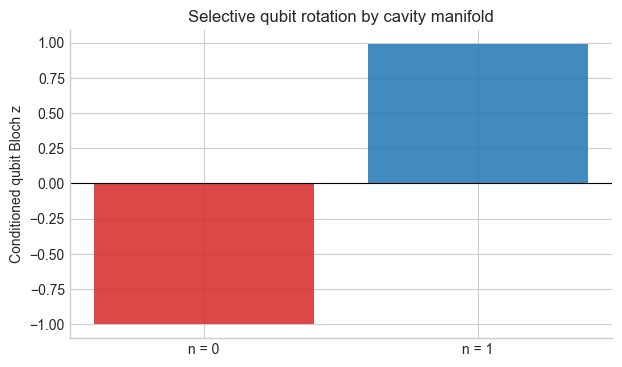

Active multitone components used by the pulse builder:
{'n': 0, 'omega_rad_s': -0.0, 'amp_rad_s': 2617993.877991494, 'phase_rad': 0.0}


In [27]:
fig, ax = plt.subplots()
ax.bar([0, 1], sqr_z, color=["tab:red", "tab:blue"], alpha=0.85)
ax.axhline(0.0, color="k", lw=0.8)
ax.set_xticks([0, 1], labels=["n = 0", "n = 1"])
ax.set_ylabel("Conditioned qubit Bloch z")
ax.set_title("Selective qubit rotation by cavity manifold")
plt.show()

print("Active multitone components used by the pulse builder:")
for tone in sqr_meta["active_tones"]:
    print(tone)


**Takeaway.** This is the pulse-level bosonic-control path rather than an ideal operator shortcut. The cavity-selective action comes from the dispersive model plus the multitone SQR pulse builder.


## 10. Optional Advanced Example: Sideband Swap

The two-mode runtime also exposes a direct `sideband` drive target. On resonance it swaps an excitation between the qubit and the cavity, producing vacuum-Rabi-like oscillations between `|e,0>` and `|g,1>`.


In [28]:
sideband_model = DispersiveTransmonCavityModel(
    omega_c=0.0,
    omega_q=0.0,
    alpha=0.0,
    chi=0.0,
    kerr=0.0,
    n_cav=4,
    n_tr=2,
)
sideband_coupling = 0.25
sideband_pulse = Pulse("sb", 0.0, 8.0, square_envelope, amp=sideband_coupling, label="sideband_drive")


In [29]:
sideband_compiled = SequenceCompiler(dt=0.02).compile([sideband_pulse], t_end=8.0)
sideband_result = simulate_sequence(
    sideband_model,
    sideband_compiled,
    sideband_model.basis_state(1, 0),
    {"sb": "sideband"},
    SimulationConfig(store_states=True),
)

p_e0 = np.array([abs(sideband_model.basis_state(1, 0).overlap(state)) ** 2 for state in sideband_result.states], dtype=float)
p_g1 = np.array([abs(sideband_model.basis_state(0, 1).overlap(state)) ** 2 for state in sideband_result.states], dtype=float)


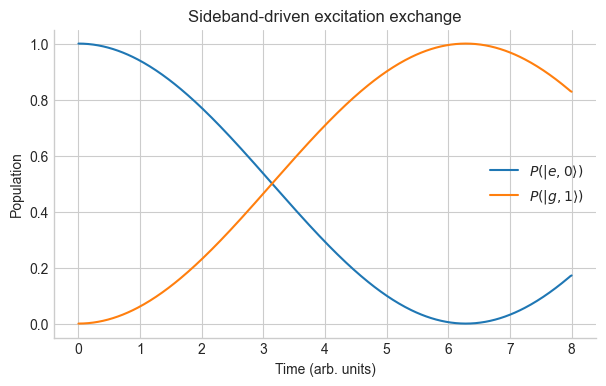

Maximum transfer to |g,1>: 1.000


In [30]:
fig, ax = plt.subplots()
ax.plot(sideband_compiled.tlist, p_e0, label=r"$P(|e,0\rangle)$")
ax.plot(sideband_compiled.tlist, p_g1, label=r"$P(|g,1\rangle)$")
ax.set_xlabel("Time (arb. units)")
ax.set_ylabel("Population")
ax.set_title("Sideband-driven excitation exchange")
ax.legend()
plt.show()

print(f"Maximum transfer to |g,1>: {np.max(p_g1):.3f}")


**Takeaway.** The sideband example uses the low-level API directly: a single `Pulse`, a `drive_ops` entry targeting `"sideband"`, and population extraction from the simulated state trajectory.
